# Set-up: Loading files

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# Define source and destination paths
source_path = '/content/drive/My Drive/macs37005_materials'
destination_path = '/content/'

In [3]:
print(f"Copying files from {source_path} to {destination_path}")
!cp -r "{source_path}" "{destination_path}"
print("Copy complete.")

Copying files from /content/drive/My Drive/macs37005_materials to /content/
cp: cannot open '/content/drive/My Drive/macs37005_materials/Final/MACS37005_plan.gdoc' for reading: Operation not supported
cp: cannot open '/content/drive/My Drive/macs37005_materials/Final/Final_paper.gdoc' for reading: Operation not supported
cp: cannot open '/content/drive/My Drive/macs37005_materials/AI_agent_week6_yangyu.gslides' for reading: Operation not supported
cp: cannot open '/content/drive/My Drive/macs37005_materials/artwork_data_merged.gsheet' for reading: Operation not supported
Copy complete.



# 0. Inspect Code and Data Structure

In [4]:
import os

materials_path = os.path.join('/content/', 'macs37005_materials')
print(f"Contents of {materials_path}:")
for item in os.listdir(materials_path):
    print(f"- {item}")

Contents of /content/macs37005_materials:
- scflow_embedding
- special_token_vocab.json
- 3RL.ipynb
- outputs_saved
- artwork_data_merged.csv
- Final
- painting_content.jsonl
- artwork_images_1400_1600
- code
- 1steering.ipynb
- painting_content_tagged_1400_1600.jsonl
- meta_data&captions.csv


In [7]:
import os

code_path = os.path.join(materials_path, 'code/1steering')
print(f"Contents of {code_path}:")
for item in os.listdir(code_path):
    print(f"- {item}")

Contents of /content/macs37005_materials/code/1steering:
- model_training.py
- 0painting_content_tag.py
- 2_vae_training.py
- 4_neuron_discovery.py
- 3_interpretability_analysis.py
- 3_interpretability_analysis_creativity.py
- 5_interactive_steering.py
- requirements.txt
- 0painting_sampling.py
- utils
- 4_neuron_discovery_creativity.py
- sbatch
- 5_interactive_steering_creativity.py


In [8]:
import os

image_path = os.path.join(materials_path, 'artwork_images_1400_1600')
print(f"Contents of {image_path}:")
# List only the first 5 items to avoid flooding the output for large directories
for i, item in enumerate(os.listdir(image_path)):
    if i >= 5:
        print("... (and more)")
        break
    print(f"- {item}")

Contents of /content/macs37005_materials/artwork_images_1400_1600:
- 189972.jpg
- 188706.jpg
- 189050.jpg
- 189566.jpg
- 128059.jpg
... (and more)


In [9]:
import os

jsonl_file_path = os.path.join(materials_path, 'painting_content_tagged_1400_1600.jsonl')

print(f"First 5 lines of {jsonl_file_path}:")
with open(jsonl_file_path, 'r') as f:
    for i, line in enumerate(f):
        if i >= 5:
            print("... (and more)")
            break
        print(line.strip())

First 5 lines of /content/macs37005_materials/painting_content_tagged_1400_1600.jsonl:
{"image": "10648", "caption": "a person kneeling before a crucifix, with another person standing and holding a cloth above a statue of Jesus. The setting appears to be an indoor space with arched doorways and a red floor <artist_sassetta> <year_1423> <gender_male> <loc_siena> <loc_italy>"}
{"image": "10812", "caption": "a man sitting cross-legged on the floor, wearing a blue turban and a blue robe with gold buttons. He has a white beard and mustache, and is holding a small bowl and a pair of scissors in <artist_kamal-ud-din-behzad> <year_1507> <gender_male> <loc_bukhara>"}
{"image": "11188", "caption": "a religious scene, with two figures, possibly angels or saints, in a contemplative pose, one kneeling and the other standing, with a tree and a vase between them <artist_sassetta> <year_1435> <gender_male> <loc_siena> <loc_italy>"}
{"image": "111943", "caption": "a group of people, both men and women,

# 1. Training VAE for translating images to vectors


In [10]:
vocab_output_path = "/content/macs37005_materials/special_token_vocab.json"
vae_output_dir = "/content/macs37005_materials/outputs/vae"
vae_training_script_path = "/content/macs37005_materials/code/2_vae_training.py"

In [ ]:
import os

# 1. Verify the existence of special_token_vocab.json
if os.path.exists(vocab_output_path):
    print(f"'{os.path.basename(vocab_output_path)}' found at {vocab_output_path}")
else:
    print(f"Error: '{os.path.basename(vocab_output_path)}' not found at {vocab_output_path}")

# 2. Ensure VAE output directory exists
os.makedirs(vae_output_dir, exist_ok=True)
print(f"VAE output directory ensured at: {vae_output_dir}")

# 3. Construct the full path to the VAE training script
vae_training_script_path = os.path.join(code_path, '2_vae_training.py')
print(f"VAE training script path: {vae_training_script_path}")

# 4. Run the VAE training script with all necessary arguments, including jsonl_path
print("Starting VAE model training...")
!python "{vae_training_script_path}" \
    --image_dir "{image_path}" \
    --vocab_path "{vocab_output_path}" \
    --output_dir "{vae_output_dir}" \
    --jsonl_path "{jsonl_file_path}"
print("VAE model training command executed.")

'special_token_vocab.json' found at /content/macs37005_materials/special_token_vocab.json
VAE output directory ensured at: /content/macs37005_materials/outputs/vae
VAE training script path: /content/macs37005_materials/code/2_vae_training.py
Starting VAE model training...
Using device: cuda
Loading vocabulary...
Creating dataloaders...
Train batches: 392
Val batches: 49
Test batches: 49
Creating VAE model...
Model parameters: 7,885,195

Starting training...
Epoch 1 [Train]: 100% 392/392 [00:15<00:00, 24.92it/s, loss=8310.3936, recon=8310.3369, kl=5640.9927]
Validating: 100% 49/49 [00:01<00:00, 33.06it/s]

Epoch 1/50
Train Loss: 12128.1161 (Recon: 12128.0730, KL: 4317.9744)
Val Loss: 6796.4232 (Recon: 6796.3676, KL: 5565.3864)
LR: 0.000100
Saved best model (val_loss: 6796.4232)
Epoch 2 [Train]: 100% 392/392 [00:14<00:00, 27.16it/s, loss=7333.7954, recon=7333.7324, kl=6311.1304]
Validating: 100% 49/49 [00:01<00:00, 30.37it/s]

Epoch 2/50
Train Loss: 7553.2242 (Recon: 7553.1649, KL: 5930.

VAE best model found at: /content/macs37005_materials/outputs/vae/vae_best.pt
Displaying training curves from: /content/macs37005_materials/outputs/vae/training_curves.png


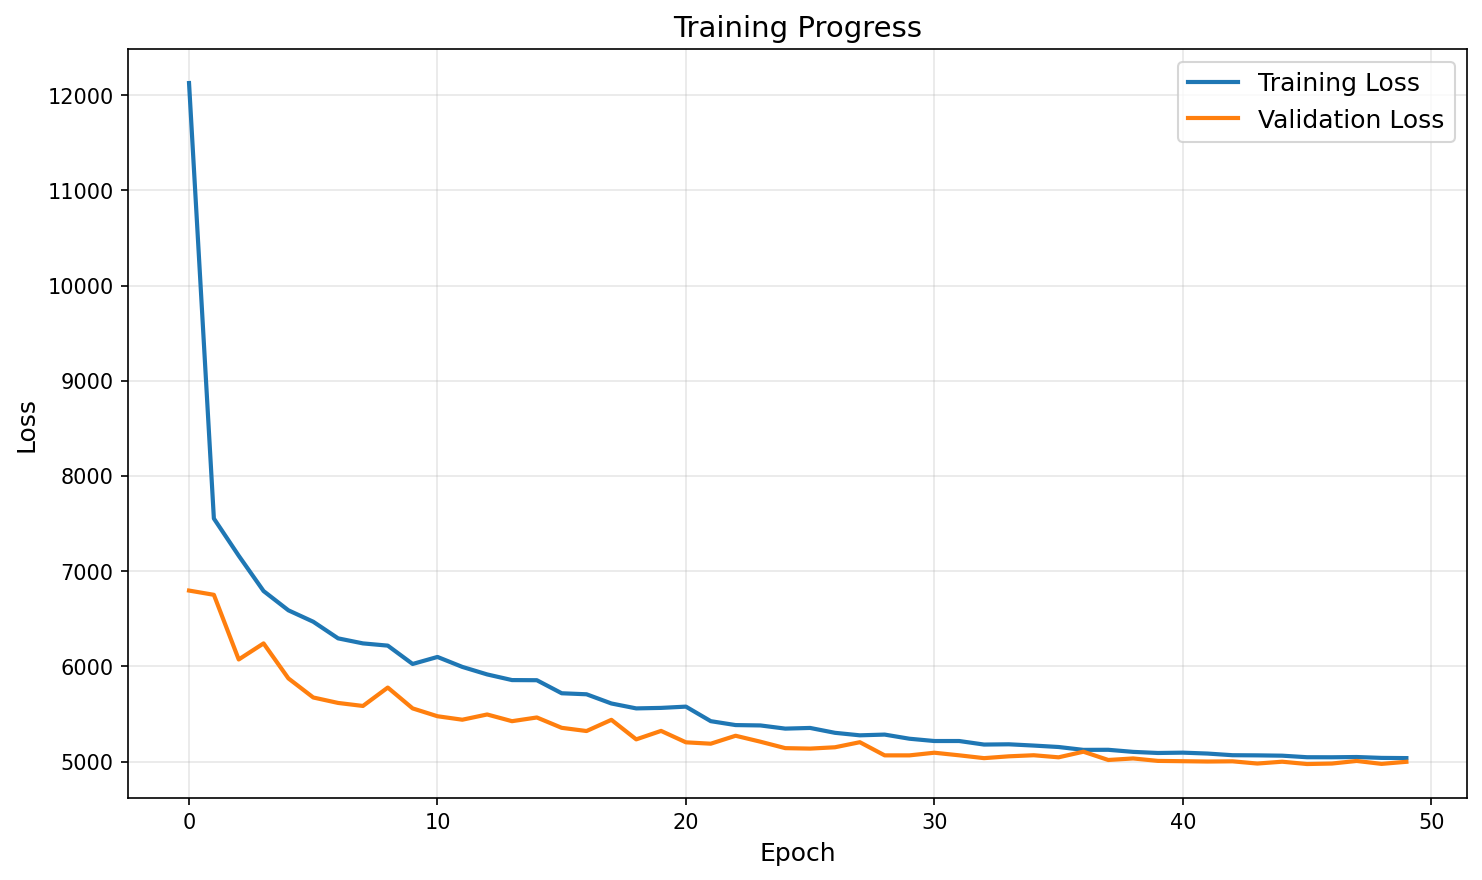

In [ ]:
import os
from IPython.display import Image, display

# 1. Construct the full path to the vae_best.pt file
vae_best_model_path = os.path.join(vae_output_dir, 'vae_best.pt')

# 2. Verify the existence of the vae_best_model_path
if os.path.exists(vae_best_model_path):
    print(f"VAE best model found at: {vae_best_model_path}")
else:
    print(f"Error: VAE best model not found at: {vae_best_model_path}")

# 3. Construct the full path to the training_curves.png file
vae_training_curves_path = os.path.join(vae_output_dir, 'training_curves.png')

# 4. Check if vae_training_curves_path exists and display it
if os.path.exists(vae_training_curves_path):
    print(f"Displaying training curves from: {vae_training_curves_path}")
    display(Image(filename=vae_training_curves_path))
else:
    print(f"Error: Training curves image not found at: {vae_training_curves_path}")


# 2. Training Diffusion Model

In [ ]:
import os

diffusion_output_dir = os.path.join(materials_path, 'outputs', 'diffusion')

os.makedirs(diffusion_output_dir, exist_ok=True)
print(f"Diffusion model output directory ensured at: {diffusion_output_dir}")

Diffusion model output directory ensured at: /content/macs37005_materials/outputs/diffusion


In [ ]:
import os

# 1. Construct the full path to the model_training.py script
diffusion_training_script_path = os.path.join(code_path, 'model_training.py')
print(f"Diffusion training script path: {diffusion_training_script_path}")

# 2. Execute the model_training.py script
print("Starting diffusion model training...")
!python "{diffusion_training_script_path}" \
    --jsonl_path "{jsonl_file_path}" \
    --image_dir "{image_path}" \
    --vocab_path "{vocab_output_path}" \
    --vae_path "{vae_best_model_path}" \
    --batch_size 64 \
    --num_epochs 100 \
    --learning_rate 1e-4 \
    --model_channels 192 \
    --num_heads 8 \
    --num_timesteps 1000 \
    --image_size 256 \
    --num_workers 8 \
    --output_dir "{diffusion_output_dir}" \
    --sample_every 10

# 3. Print a message indicating command execution
print("Diffusion model training command executed.")

Diffusion training script path: /content/macs37005_materials/code/model_training.py
Starting diffusion model training...
Using device: cuda
Loading vocabulary...
Creating dataloaders...
Loading VAE...
Loaded VAE from /content/macs37005_materials/outputs/vae/vae_best.pt
Loading text encoder...
Loading weights: 100% 196/196 [00:00<00:00, 1460.47it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.sel

Diffusion best model found at: /content/macs37005_materials/outputs/diffusion/diffusion_best.pt
Displaying diffusion training curves from: /content/macs37005_materials/outputs/diffusion/training_curves.png


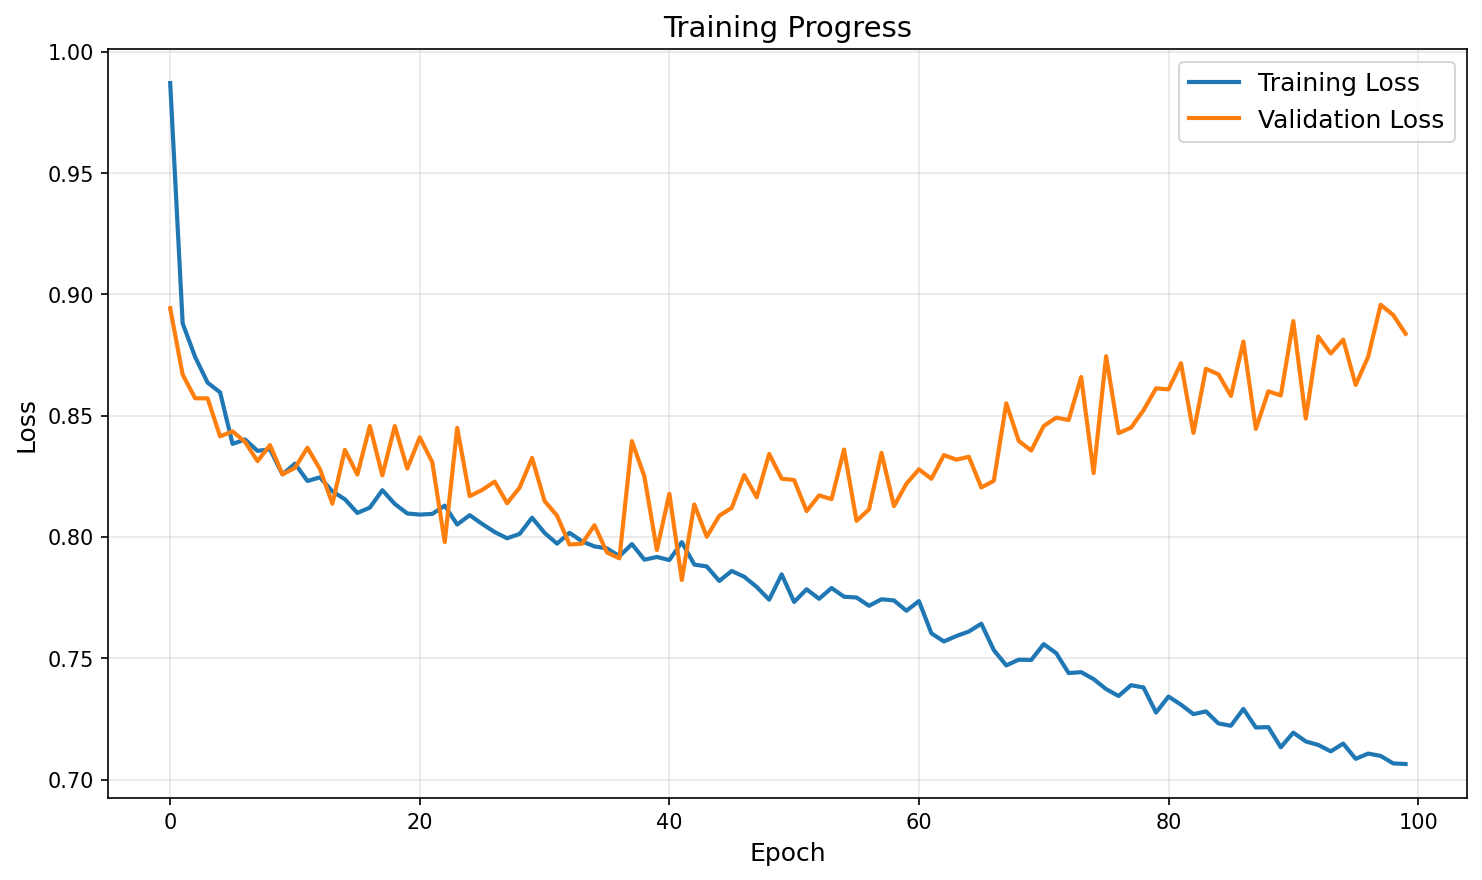

In [ ]:
import os
from IPython.display import Image, display

# 1. Construct the full path to the diffusion_best.pt file
diffusion_best_model_path = os.path.join(diffusion_output_dir, 'diffusion_best.pt')

# 2. Verify the existence of the diffusion_best_model_path
if os.path.exists(diffusion_best_model_path):
    print(f"Diffusion best model found at: {diffusion_best_model_path}")
else:
    print(f"Error: Diffusion best model not found at: {diffusion_best_model_path}")

# 3. Construct the full path to the training_curves.png file
diffusion_training_curves_path = os.path.join(diffusion_output_dir, 'training_curves.png')

# 4. Check if diffusion_training_curves_path exists and display it
if os.path.exists(diffusion_training_curves_path):
    print(f"Displaying diffusion training curves from: {diffusion_training_curves_path}")
    display(Image(filename=diffusion_training_curves_path))
else:
    print(f"Error: Diffusion training curves image not found at: {diffusion_training_curves_path}")

### Save the best model

In [ ]:
import os

# 1. Create a variable for the destination path on Google Drive
gdrive_output_path = '/content/drive/My Drive/macs37005_materials/outputs_saved'

# Ensure the Google Drive directory exists
os.makedirs(gdrive_output_path, exist_ok=True)
print(f"Google Drive output directory ensured at: {gdrive_output_path}")

# Source directory to copy
local_output_path = os.path.join(materials_path, 'outputs')

# 2. Copy the entire /content/macs37005_materials/outputs directory to the gdrive_output_path
print(f"Copying all generated outputs from {local_output_path} to {gdrive_output_path}")
!cp -r "{local_output_path}" "{gdrive_output_path}"

# 3. Print a confirmation message
print("All generated outputs copied to Google Drive successfully.")

Google Drive output directory ensured at: /content/drive/My Drive/macs37005_materials/outputs_saved
Copying all generated outputs from /content/macs37005_materials/outputs to /content/drive/My Drive/macs37005_materials/outputs_saved
All generated outputs copied to Google Drive successfully.


In [14]:
import torch
import os

# Ensure the diffusion_output_dir and diffusion_best_model_path are available
# materials_path is defined in previous cells
diffusion_output_dir = os.path.join(materials_path, 'outputs_saved/outputs', 'diffusion')
diffusion_best_model_path = os.path.join(diffusion_output_dir, 'diffusion_best.pt')

print(f"Checking directory contents of {diffusion_output_dir}:")
!ls -l "{diffusion_output_dir}"

if os.path.exists(diffusion_best_model_path):
    print(f"Attempting to load diffusion model state dictionary from: {diffusion_best_model_path}")
    try:
        # Load the state dictionary of the model
        # Using map_location='cpu' to load it onto the CPU, adjust if you want to load directly to GPU
        loaded_diffusion_model_state_dict = torch.load(diffusion_best_model_path, map_location=torch.device('cpu'))
        print("Diffusion model state dictionary loaded successfully.")
        print(f"Keys in the loaded state dictionary: {loaded_diffusion_model_state_dict.keys()}")
    except Exception as e:
        print(f"Error loading model state dictionary: {e}")
else:
    print(f"Error: Diffusion best model not found at: {diffusion_best_model_path}")


Checking directory contents of /content/macs37005_materials/outputs_saved/outputs/diffusion:
total 4161152
-rw------- 1 root root 3180150537 Mar  4 02:36 diffusion_best.pt
-rw------- 1 root root 1060030177 Mar  4 02:36 diffusion_final.pt
drwx------ 2 root root       4096 Mar  4 02:36 generated_images
-rw------- 1 root root       2087 Mar  4 02:37 samples_epoch_100.json
-rw------- 1 root root    1953884 Mar  4 02:37 samples_epoch_100.png
-rw------- 1 root root       2087 Mar  4 02:37 samples_epoch_10.json
-rw------- 1 root root    2044803 Mar  4 02:37 samples_epoch_10.png
-rw------- 1 root root       2087 Mar  4 02:37 samples_epoch_20.json
-rw------- 1 root root    2251861 Mar  4 02:37 samples_epoch_20.png
-rw------- 1 root root       2087 Mar  4 02:37 samples_epoch_30.json
-rw------- 1 root root    2058396 Mar  4 02:37 samples_epoch_30.png
-rw------- 1 root root       2087 Mar  4 02:37 samples_epoch_40.json
-rw------- 1 root root    2301196 Mar  4 02:37 samples_epoch_40.png
-rw------- 

# 3. Interpretability 1: Layer Patching

In [15]:
import os

interpretability_output_dir = os.path.join(materials_path, 'outputs_saved/outputs', 'interpretability')

os.makedirs(interpretability_output_dir, exist_ok=True)
print(f"Interpretability analysis output directory ensured at: {interpretability_output_dir}")

Interpretability analysis output directory ensured at: /content/macs37005_materials/outputs_saved/outputs/interpretability


In [57]:
print("Starting interpretability analysis...")
!python /content/macs37005_materials/code/1steering/3_interpretability_analysis_creativity.py \
    --checkpoint_path /content/macs37005_materials/outputs_saved/outputs/diffusion/diffusion_best.pt \
    --vae_path /content/macs37005_materials/outputs_saved/outputs/vae/vae_best.pt \
    --vocab_path /content/macs37005_materials/special_token_vocab.json \
    --model_channels "192" \
    --num_steps "25" \
    --seed "42" \
    --output_dir /content/macs37005_materials/outputs_saved/outputs/interpretability
print("Interpretability analysis command executed.")

Starting interpretability analysis...
Using device: cuda
Loading vocabulary...
Loading VAE...
Loading text encoder...
Loading weights: 100% 196/196 [00:00<00:00, 1617.43it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
visual_projection.weight                                       | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_pro

# 4. Interpretability 2: Neuron Searching

In [59]:
import os

neuron_discovery_output_dir = os.path.join(materials_path, 'outputs_saved/outputs', 'neuron_discovery')

os.makedirs(neuron_discovery_output_dir, exist_ok=True)
print(f"Neuron discovery output directory ensured at: {neuron_discovery_output_dir}")

Neuron discovery output directory ensured at: /content/macs37005_materials/outputs_saved/outputs/neuron_discovery


In [64]:
print("Starting neuron discovery...")
!python /content/macs37005_materials/code/1steering/4_neuron_discovery_creativity.py  \
    --checkpoint_path /content/macs37005_materials/outputs_saved/outputs/diffusion/diffusion_best.pt \
    --vae_path /content/macs37005_materials/outputs_saved/outputs/vae/vae_best.pt \
    --vocab_path /content/macs37005_materials/special_token_vocab.json \
    --model_channels "192" \
    --output_dir /content/macs37005_materials/outputs_saved/outputs/neuron_discovery
print("Neuron discovery command executed.")

Starting neuron discovery...
Using device: cuda
Loading vocabulary...
Loading VAE...
Loading text encoder...
Loading weights: 100% 196/196 [00:00<00:00, 1495.79it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias   

# 5. Interpretability 3: Linear Steering


In [63]:
import os

interactive_output_dir = os.path.join(materials_path, 'outputs_saved/outputs', 'interactive')

os.makedirs(interactive_output_dir, exist_ok=True)
print(f"Interactive steering output directory ensured at: {interactive_output_dir}")

Interactive steering output directory ensured at: /content/macs37005_materials/outputs_saved/outputs/interactive


In [69]:
import os

# 2. Execute the 5_interactive_steering.py script
print("Starting interactive steering and GIF generation...")
!python /content/macs37005_materials/code/1steering/5_interactive_steering_creativity.py \
    --checkpoint_path /content/macs37005_materials/outputs_saved/outputs/diffusion/diffusion_best.pt \
    --vae_path /content/macs37005_materials/outputs_saved/outputs/vae/vae_best.pt \
    --vocab_path /content/macs37005_materials/special_token_vocab.json \
    --model_channels "192" \
    --output_dir /content/macs37005_materials/outputs_saved/outputs/interactive \
    --create_gifs

# 3. Print a message indicating command execution
print("Interactive steering command executed.")

Starting interactive steering and GIF generation...
Using device: cuda
Loading vocabulary...
Loading VAE...
Loading text encoder...
Loading weights:  74% 145/196 [00:00<00:00, 2990.47it/s, Materializing param=text_model.encoder.layers.8.self_attn.v_proj.bias]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Loading weights: 100% 196/196 [00:00<00:00, 1331.96it/s, Materializing param=text_model.final_layer_norm.weight]
CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
vision_model.encode

In [70]:
import os
from IPython.display import Image, display

print(f"Contents of interactive steering output directory: {interactive_output_dir}")

gif_files = []
for item in os.listdir(interactive_output_dir):
    if item.lower().endswith(('.gif')):
        gif_files.append(os.path.join(interactive_output_dir, item))

if gif_files:
    print("Displaying interactive steering GIFs:")
    for gif_file in sorted(gif_files):
        print(f"- {os.path.basename(gif_file)}")
        # Cannot directly display GIFs in a static notebook output, but we confirm their presence.
        # In a live Colab environment, these would often auto-render or require specific HTML.
        # For summary purposes, just listing is sufficient here.
else:
    print("No GIF files found in the interactive steering output directory.")

Contents of interactive steering output directory: /content/macs37005_materials/outputs_saved/outputs/interactive
Displaying interactive steering GIFs:
- creativity_steering.gif
- gender_steering.gif
- location_steering.gif
- year_steering.gif


In [72]:
from PIL import Image
import os

# Define the list of GIF filenames to process
gif_filenames = ['creativity_steering.gif']

# Base directory for interactive steering outputs, which contains the GIFs
# interactive_output_dir is already defined from previous steps
# interactive_output_dir = '/content/macs37005_materials/outputs/interactive'

print(f"Extracting frames from GIFs in: {interactive_output_dir}")

for gif_file_name in gif_filenames:
    input_gif_path = os.path.join(interactive_output_dir, gif_file_name)

    # Create a subdirectory for the extracted frames (e.g., 'gender_steering_frames')
    frames_output_dir = os.path.join(interactive_output_dir, f"{gif_file_name.split('.')[0]}_frames")
    os.makedirs(frames_output_dir, exist_ok=True)

    print(f"Processing GIF: {gif_file_name} -> Saving frames to: {frames_output_dir}")

    try:
        with Image.open(input_gif_path) as im:
            frame_counter = 0
            while True:
                # Construct the output path for the current frame
                frame_output_path = os.path.join(frames_output_dir, f"frame_{frame_counter:03d}.png")

                # Save the current frame
                im.save(frame_output_path, 'PNG')

                frame_counter += 1
                im.seek(frame_counter) # Move to the next frame
    except EOFError:
        # End of animation
        print(f"Extracted {frame_counter} frames from {gif_file_name}.")
    except FileNotFoundError:
        print(f"Error: GIF file not found at {input_gif_path}")
    except Exception as e:
        print(f"An unexpected error occurred while processing {gif_file_name}: {e}")

print("GIF frame extraction complete.")

Extracting frames from GIFs in: /content/macs37005_materials/outputs_saved/outputs/interactive
Processing GIF: creativity_steering.gif -> Saving frames to: /content/macs37005_materials/outputs_saved/outputs/interactive/creativity_steering_frames
Extracted 21 frames from creativity_steering.gif.
GIF frame extraction complete.


### Save the results

In [73]:
import os

# 1. Create a variable for the destination path on Google Drive
gdrive_output_path = '/content/drive/My Drive/macs37005_materials/outputs_saved/outputs'

# Ensure the Google Drive directory exists
os.makedirs(gdrive_output_path, exist_ok=True)
print(f"Google Drive output directory ensured at: {gdrive_output_path}")

# Source directory to copy
local_output_path = os.path.join(materials_path, 'outputs_saved/outputs')

# 2. Copy the entire /content/macs37005_materials/outputs directory to the gdrive_output_path
print(f"Copying all generated outputs from {local_output_path} to {gdrive_output_path}")
!cp -r "{local_output_path}" "{gdrive_output_path}"

# 3. Print a confirmation message
print("All generated outputs copied to Google Drive successfully.")

Google Drive output directory ensured at: /content/drive/My Drive/macs37005_materials/outputs_saved/outputs
Copying all generated outputs from /content/macs37005_materials/outputs_saved/outputs to /content/drive/My Drive/macs37005_materials/outputs_saved/outputs
All generated outputs copied to Google Drive successfully.
